# Shallow 1 Dimension Convolutional Network

- splitto train, val, test
- data augmentation sul train set originale con step e linear
- scaling fit su train e transform su validation/test
- creazione tabella lag features con sequenze su tutti i set
- reshape per CNN: da (samples, timesteps) a (samples, timesteps, 1) [1 perchè univariato]

In [1]:
%load_ext autoreload
%autoreload 2

## Import

In [2]:
from src.config import set_seeds, get_complete_path, MODELS_DIR
import src.pipeline as pipe
import src.models as mod
import src.models.nn as nn
import src.evaluation as eval
import src.visualization as visual
import src.reporting as rep
import pandas as pd
import tensorflow as tf
import numpy as np
import os
import gc
from tensorflow.keras.callbacks import ModelCheckpoint # type: ignore

In [3]:
set_seeds()

In [4]:
INDICATORS = ['Livestock production index (2014-2016 = 100)']


# 'Fertilizer consumption (% of fertilizer production)'

## Data upload

In [5]:
df = pipe.load_data()

Dataset caricato: 65 anni, 28 variabili.


## Preprocessing
- splitting in train, validation and test set
- augmentation with step function and linear interpolation + jitter on original train set + visualization
- creation of dictionary with all the subsets (unscaled values)
- scaling of all the datasets
- creation of dictionary with all the scaled datasets 
- lag features table of scaled datasets
- creation of dictionary with all the lag features tables of the scaled datasets

============================== LIVESTOCK PRODUCTION INDEX (2014-2016 = 100) ==============================
Train: 1961-2003 (43 obs)
Val:   2004-2013 (10 obs)
Test:  2014-2022 (9 obs)
Grafico salvato in: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\AUGMENTATION\AUG_livestock_production_index.png


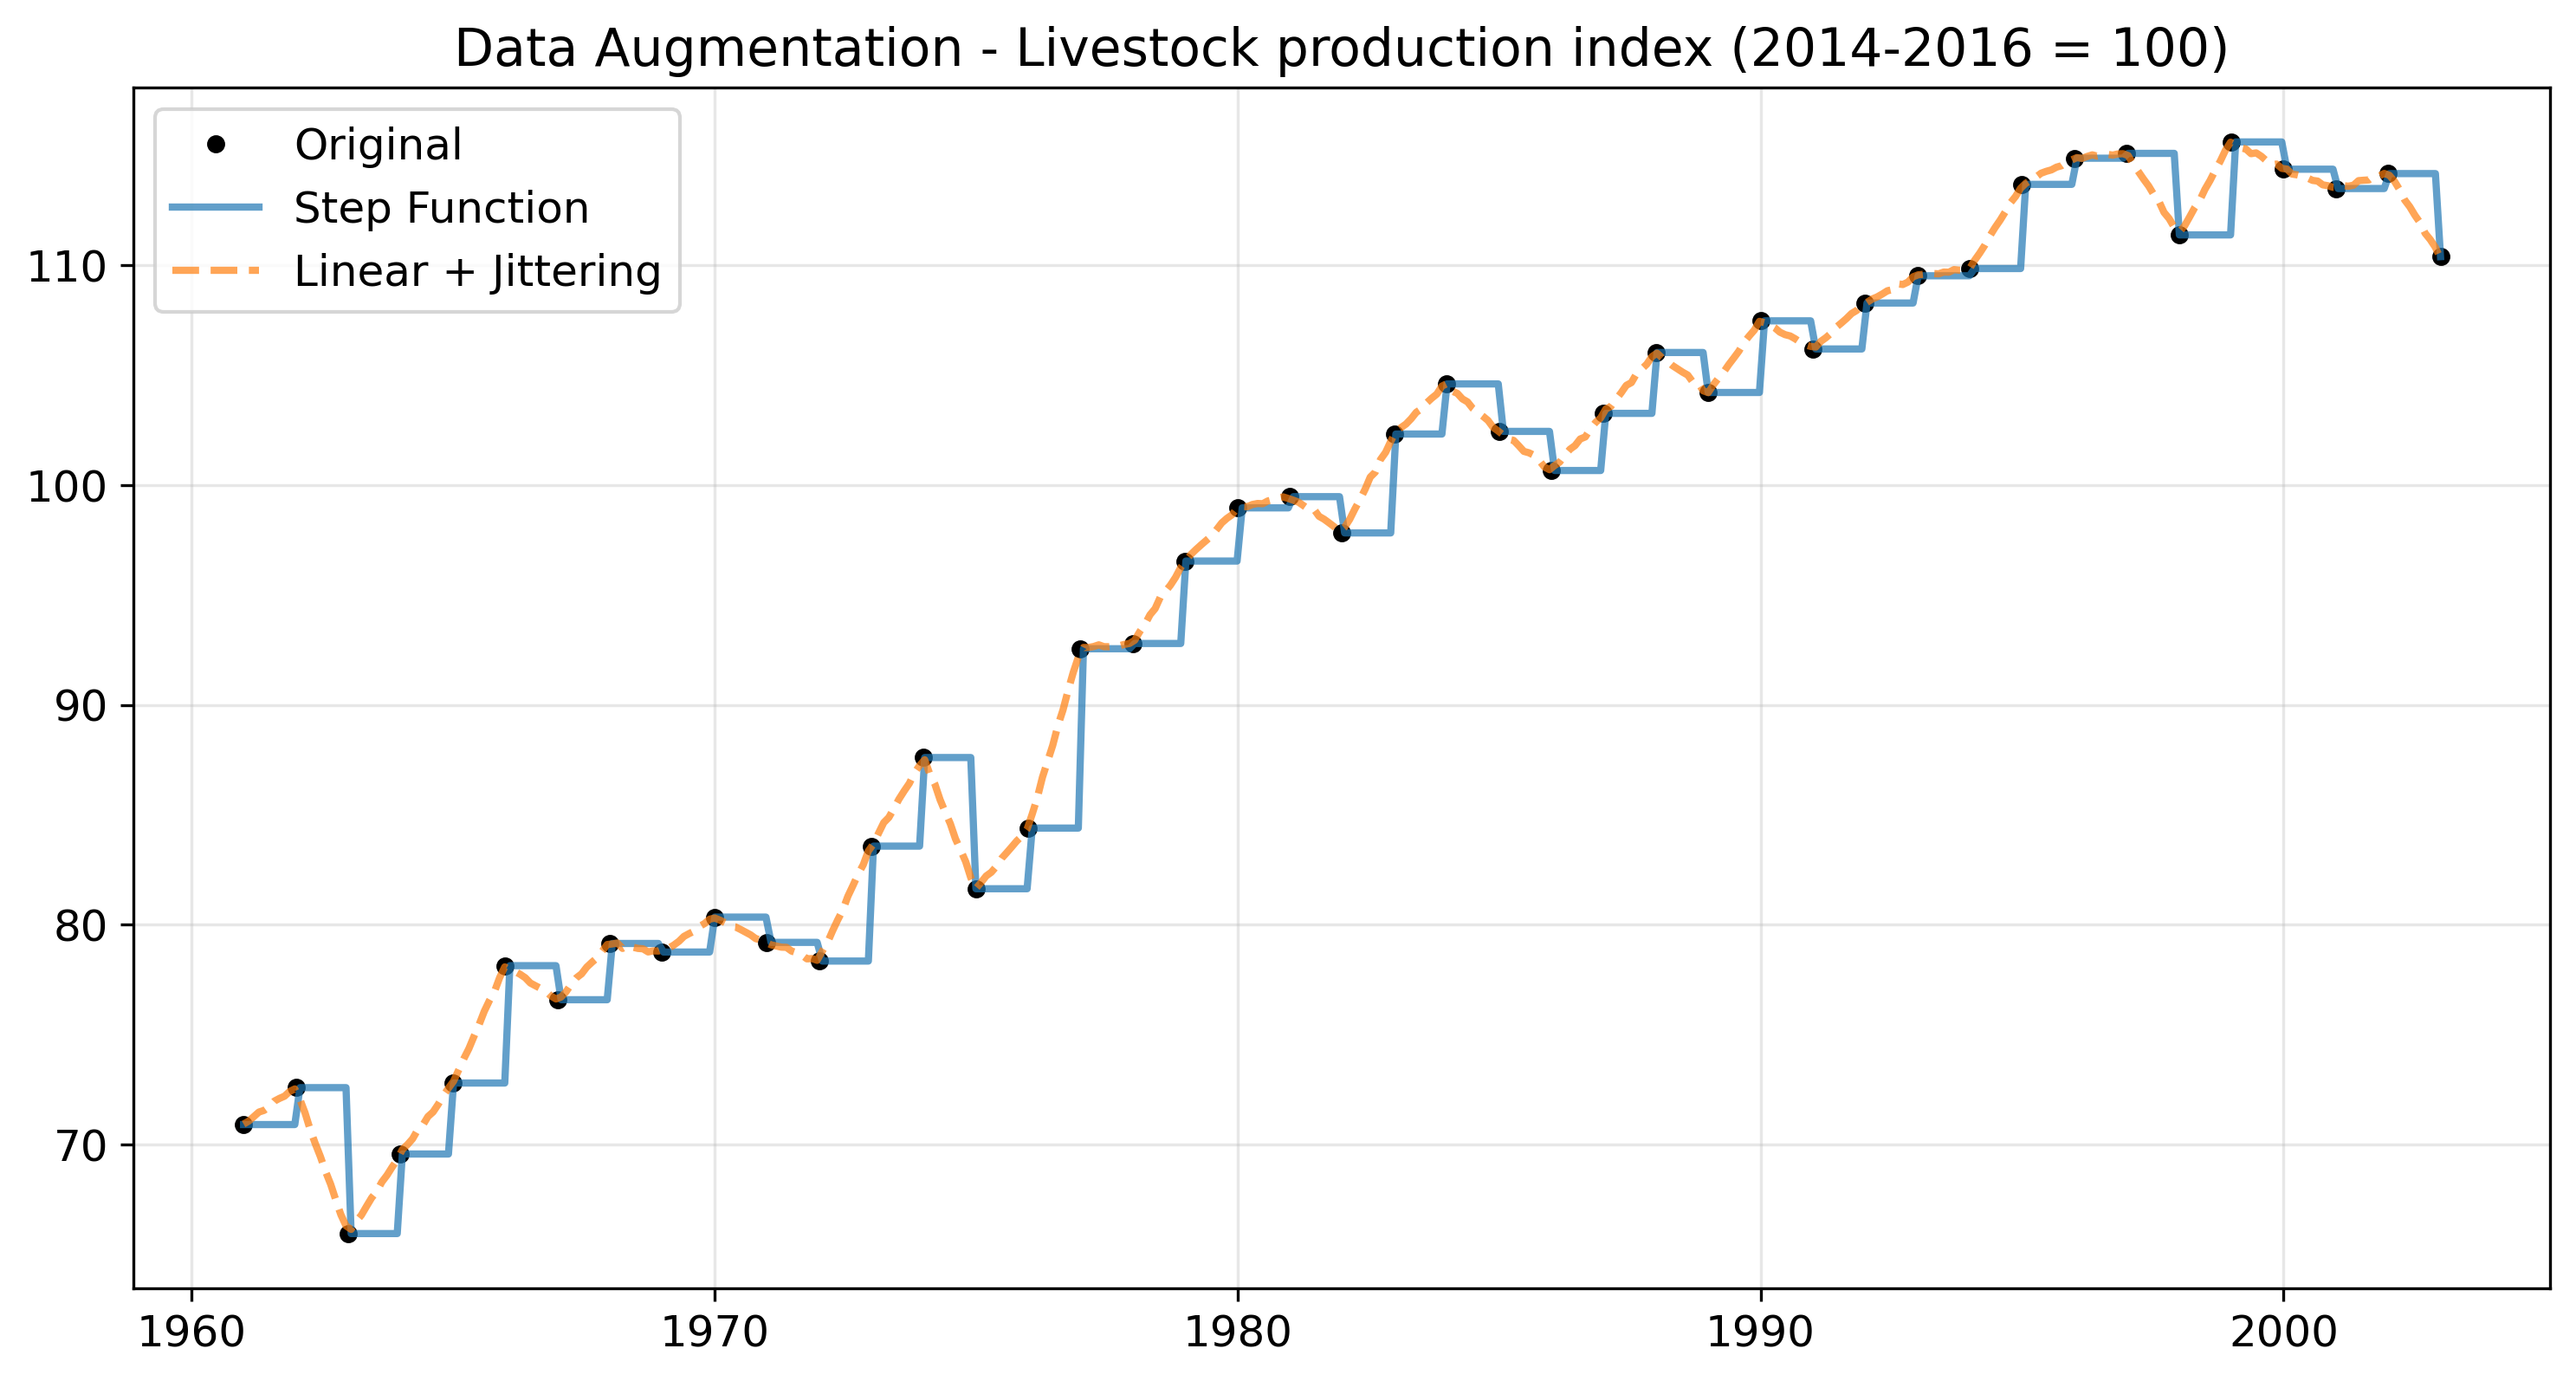

In [6]:
orig_aug_subsets = {}

for indicator in INDICATORS:
    print('='*30, indicator.upper(), '='*30)
    df_temp = df[['Year', indicator]].dropna().copy()
    df_temp.columns = ['Year', 'Value']
    train_orig, val_orig, test_orig = pipe.split_train_val_test(df_temp)    # splitto la time serie ORIGINALE
    
    x_train_vals = train_orig['Year']
    y_train_vals = train_orig['Value']
    
    df_step = pipe.augment_step_function(x_train_vals, y_train_vals, scale_factor=10)
    df_jitter = pipe.augment_linear_with_jitter(x_train_vals, y_train_vals, scale_factor=10, noise_level=0.05)
    visual.plot_augmented(indicator, df_step, df_jitter, x_train_vals, y_train_vals)
    orig_aug_subsets[indicator] = {
        'full_orig': df_temp,
        'orig_train': train_orig,
        'step_aug_train': df_step,
        'jitter_aug_train': df_jitter,
        'orig_val': val_orig,
        'orig_test': test_orig
    }

In [7]:
scaled_orig_aug_subsets = {} 
scalers_subsets = {}
for indicator in INDICATORS:
    scaled_subsets, scalers = pipe.scale_datasets(orig_aug_subsets[indicator])
    scaled_orig_aug_subsets[indicator] = scaled_subsets
    scalers_subsets[indicator] = scalers

In [8]:
scaled_table_subsets = {}
for indicator in INDICATORS:
    window_size = 3
    table_train_orig = pipe.create_lag_features_table(scaled_orig_aug_subsets[indicator]['orig_train'], window_size, step=1)
    table_train_step = pipe.create_lag_features_table(scaled_orig_aug_subsets[indicator]['step_aug_train'], window_size, step=1)
    table_train_jitter = pipe.create_lag_features_table(scaled_orig_aug_subsets[indicator]['jitter_aug_train'], window_size, step=1)
    table_val_orig = pipe.create_lag_features_table(scaled_orig_aug_subsets[indicator]['orig_val'], window_size, step=1)
    table_test_orig = pipe.create_lag_features_table(scaled_orig_aug_subsets[indicator]['orig_test'], window_size, step=1)
    scaled_table_subsets[indicator] = {
        'train_orig' : table_train_orig,
        'train_step' : table_train_step,
        'train_jitter' : table_train_jitter,
        'val_orig' : table_val_orig,
        'test_orig' : table_test_orig
    }

## Reshape

In [9]:
final_table_train_sets = {}
final_table_val_test_sets = {}

for indicator in INDICATORS:
    # X: filtra colonne ts_*
    # y: prende colonna 'target'
    X_train_orig_to_reshape = scaled_table_subsets[indicator]['train_orig'].filter(regex=r'^ts_').copy()
    y_train_orig_to_reshape = scaled_table_subsets[indicator]['train_orig']['target'].copy()
    
    X_train_step_to_reshape = scaled_table_subsets[indicator]['train_step'].filter(regex=r'^ts_').copy()
    y_train_step_to_reshape = scaled_table_subsets[indicator]['train_step']['target'].copy()
    
    X_train_jitter_to_reshape = scaled_table_subsets[indicator]['train_jitter'].filter(regex=r'^ts_').copy()
    y_train_jitter_to_reshape = scaled_table_subsets[indicator]['train_jitter']['target'].copy()
    
    X_val_orig_to_reshape = scaled_table_subsets[indicator]['val_orig'].filter(regex=r'^ts_').copy()
    y_val_orig_to_reshape = scaled_table_subsets[indicator]['val_orig']['target'].copy()
    
    X_test_orig_to_reshape = scaled_table_subsets[indicator]['test_orig'].filter(regex=r'^ts_').copy()
    y_test_orig_to_reshape = scaled_table_subsets[indicator]['test_orig']['target'].copy()
    
    # Reshape X: (samples, window_size, 1)
    X_train_orig = X_train_orig_to_reshape.values.reshape((X_train_orig_to_reshape.shape[0], X_train_orig_to_reshape.shape[1], 1))
    X_train_step = X_train_step_to_reshape.values.reshape((X_train_step_to_reshape.shape[0], X_train_step_to_reshape.shape[1], 1))
    X_train_jitter = X_train_jitter_to_reshape.values.reshape((X_train_jitter_to_reshape.shape[0], X_train_jitter_to_reshape.shape[1], 1))
    X_val_orig = X_val_orig_to_reshape.values.reshape((X_val_orig_to_reshape.shape[0], X_val_orig_to_reshape.shape[1], 1))
    X_test_orig = X_test_orig_to_reshape.values.reshape((X_test_orig_to_reshape.shape[0], X_test_orig_to_reshape.shape[1], 1))
    
    # Reshape y: (samples, 1)
    y_train_orig = y_train_orig_to_reshape.values.reshape(-1, 1)
    y_train_step = y_train_step_to_reshape.values.reshape(-1, 1)
    y_train_jitter = y_train_jitter_to_reshape.values.reshape(-1, 1)
    y_val_orig = y_val_orig_to_reshape.values.reshape(-1, 1)
    y_test_orig = y_test_orig_to_reshape.values.reshape(-1, 1)
    
    final_table_train_sets[indicator] = {
        'train_orig' : (X_train_orig, y_train_orig),
        'train_step' : (X_train_step, y_train_step),
        'train_jitter' : (X_train_jitter, y_train_jitter),
    }
    
    final_table_val_test_sets[indicator] = {
        'val_orig': (X_val_orig, y_val_orig),
        'test_orig' : (X_test_orig, y_test_orig)
    }
    
    print("train orig", X_train_orig[0], y_train_orig[0])
    print("step", X_train_step[0], y_train_step[0])
    print("jitter", X_train_jitter[0], y_train_jitter[0])
    print("val", X_val_orig[0], y_val_orig[0])
    print("test", X_test_orig[0], y_test_orig[0])

train orig [[0.09985907]
 [0.1336823 ]
 [0.        ]] [0.07288101]
step [[0.09985907]
 [0.09985907]
 [0.09985907]] [0.09985907]
jitter [[0.10035908]
 [0.10303125]
 [0.10713379]] [0.11132632]
val [[0.89249044]
 [0.88141735]
 [0.82987719]] [0.8999396]
test [[0.60539561]
 [0.71592511]
 [0.73525267]] [0.68733642]


### Parametri Architetturali
- n_filters: numero di filtri Conv1D (es. 32, 64, 128)
- kernel_size: dimensione kernel convoluzionale (es. 3, 5)
- n_conv_layers: numero di layer convoluzionali (es. 1-3 per shallow)
- pool_size: dimensione MaxPooling (es. 2)
- dense_units: neuroni nel layer Dense dopo Flatten (opzionale)
- dropout: tasso dropout per regolarizzazione
- activation: funzione attivazione ('relu', 'tanh')

### Parametri Training (già gestiti da train_model)
- learning_rate, batch_size, epochs, patience

In [10]:
results = {} 
best_model_paths = {}

params_shallow_cnn = {
    'n_filters': 32,        # numero di filtri conv1D (32, 64, 128)
    'kernel_size': 3,       # dimensione kernel convoluzionale (3,5)
    'n_conv_layers': 1,     # numero di layer convoluzionali (1-3 per shallow)
    'pool_size': 2,         # dimensione MaxPooling (2)
    'use_pooling': False,   # if True usa MaxPooling, per time serie corte provo a mettere false
    'dense_units': 50,      # neuroni nel layer Dense dopo Flatten
    'dropout': 0.2,         # tasso dropout per regolarizzazione
    'activation': 'relu',   # funzione di attivazione (relu, tanh)
    'learning_rate': 0.001  # usato da train_model
}

for indicator in INDICATORS:
    if indicator not in results:
        results[indicator] = {}
    if indicator not in best_model_paths:
        best_model_paths[indicator] = {}
    
    for ds_category in ['orig', 'step', 'jitter']:
        print(f"Processing: {indicator} | ds_category: {ds_category}")
        
        X_train = final_table_train_sets[indicator][f'train_{ds_category}'][0]  # ts_*
        y_train = final_table_train_sets[indicator][f'train_{ds_category}'][1]  # target

        X_val = final_table_val_test_sets[indicator]['val_orig'][0]     # ts_*
        y_val = final_table_val_test_sets[indicator]['val_orig'][1]     # target
        
        X_test = final_table_val_test_sets[indicator]['test_orig'][0]   # ts_*      
        y_test = final_table_val_test_sets[indicator]['test_orig'][1]   # target
        
        scaler = scalers_subsets[indicator]['scaler_y']
        
        model_name = f"shallowCNN_{ds_category}" 
        path = get_complete_path(MODELS_DIR, model_name, indicator, ext=".keras")
        
        best_model_paths[indicator][ds_category] = path
        
        checkpoint = ModelCheckpoint(
            path, 
            monitor='val_loss', 
            save_best_only=True,
            mode='min', 
            verbose=0
        )
        
        input_shape = (X_train.shape[1], X_train.shape[2]) 
        model = nn.build_cnn_model(params_shallow_cnn, input_shape)
        
        history, trained_model = nn.train_model(
            model, 
            X_train, y_train,
            X_val, y_val,
            batch_size=8,
            epochs=100,
            patience=15,
            extra_callbacks=[checkpoint]
        )
        
        pred_scaled = trained_model.predict(X_test, verbose=0)
        
        test_real = scaler.inverse_transform(y_test.reshape(-1, 1))
        pred_real = scaler.inverse_transform(pred_scaled)
        
        results[indicator][ds_category] = {
            'test_real': test_real,
            'pred_real': pred_real,
            'history': history.history['loss'],
            'metrics': eval.compute_errors(test_real, pred_real)
        }
        
        tf.keras.backend.clear_session()
        del model
        del trained_model
        gc.collect()

Processing: Livestock production index (2014-2016 = 100) | ds_category: orig

Processing: Livestock production index (2014-2016 = 100) | ds_category: step
Processing: Livestock production index (2014-2016 = 100) | ds_category: jitter


Grafico salvato in: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\CNN_shallow\cnn_shallow_livestock_production_index.png


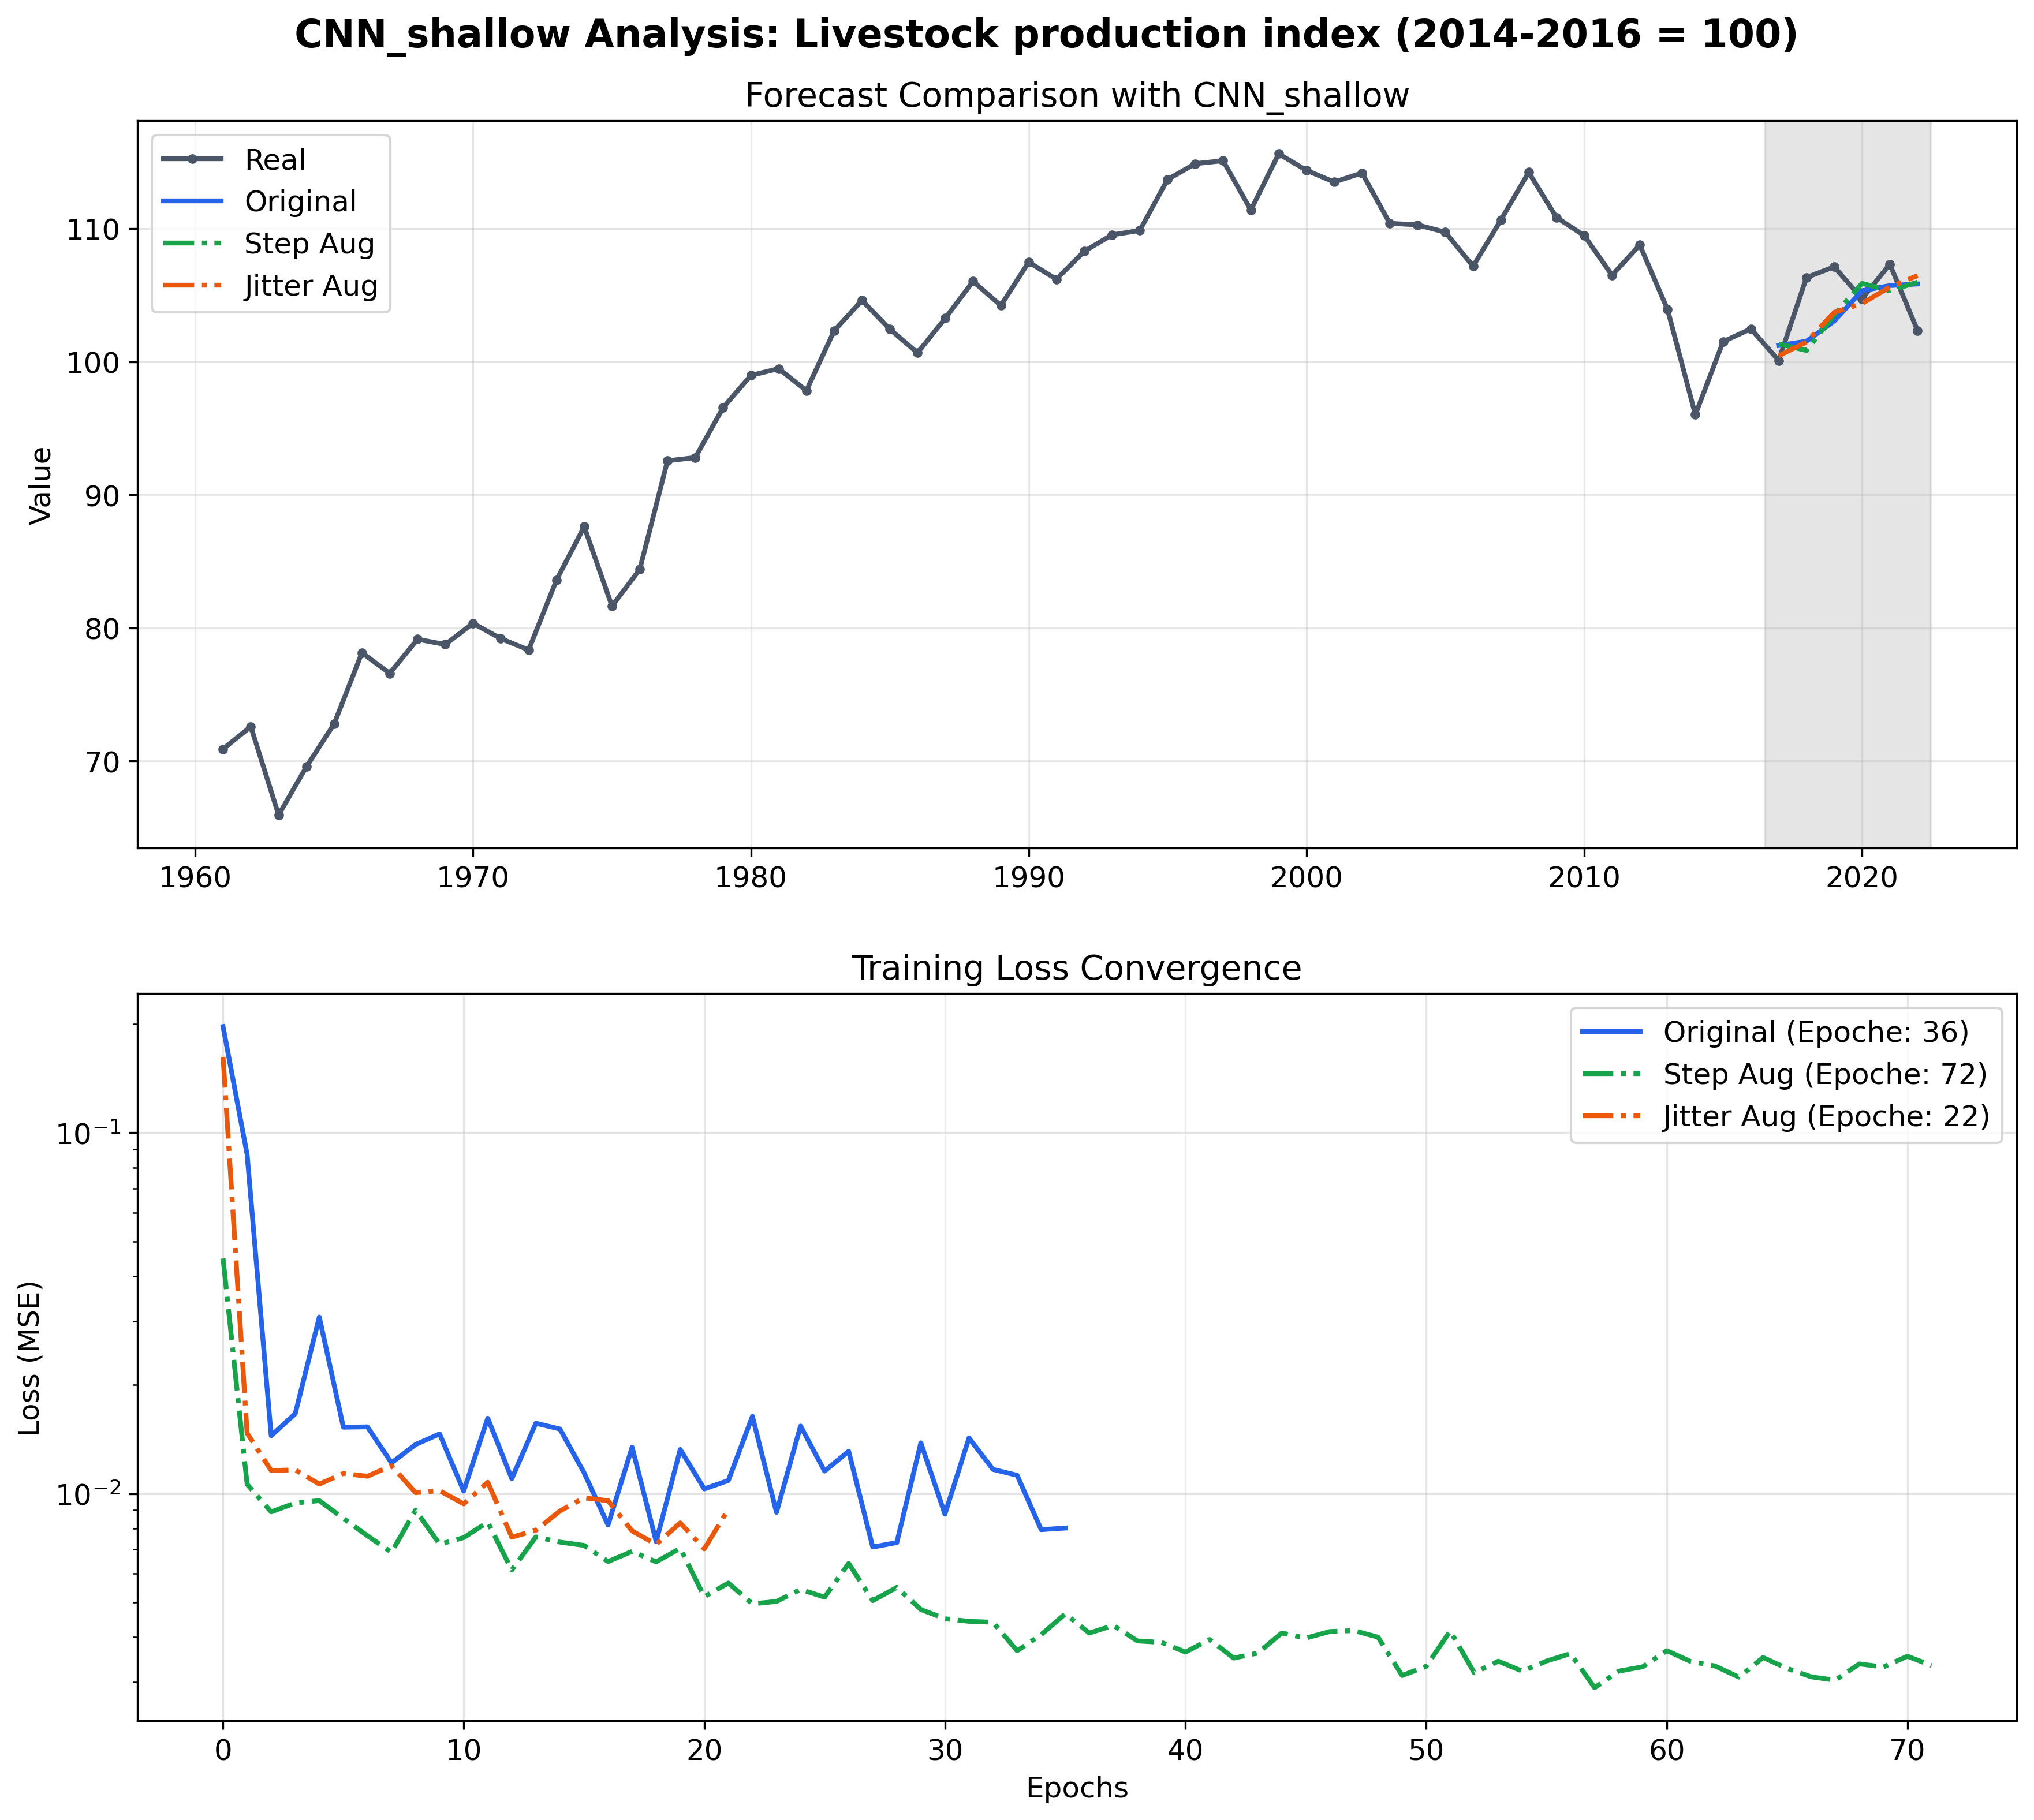

In [11]:
visual.plot_shallow_nn_preds(indicator, results, orig_aug_subsets, model_name="CNN_shallow")

In [12]:
display(best_model_paths)

{'Livestock production index (2014-2016 = 100)': {'orig': 'C:\\Users\\oldan\\Desktop\\RuralDevelopment\\progetto-tirocinio\\results\\saved_models\\shallowCNN_orig\\shallowCNN_orig_livestock_production_index.keras',
  'step': 'C:\\Users\\oldan\\Desktop\\RuralDevelopment\\progetto-tirocinio\\results\\saved_models\\shallowCNN_step\\shallowCNN_step_livestock_production_index.keras',
  'jitter': 'C:\\Users\\oldan\\Desktop\\RuralDevelopment\\progetto-tirocinio\\results\\saved_models\\shallowCNN_jitter\\shallowCNN_jitter_livestock_production_index.keras'}}

## 2030 forecasting
devo rifare tutto il preprocessing su tutta la serie temporale questa volta

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
import gc

TARGET_YEAR = 2030
WINDOW_SIZE = params_shallow_cnn.get('kernel_size', 3) + 2  # Es. 5

forecasts_2030 = {}

print(f"AVVIO REFITTING E FORECASTING FINO AL {TARGET_YEAR}")

for indicator in INDICATORS:
    print(f"\nProcessing Indicator: {indicator}")
    df_full = orig_aug_subsets[indicator]['full_orig'].sort_values('Year')
    full_values = df_full['Value'].values.reshape(-1, 1)
    
    LAST_DATA_YEAR = int(df_full['Year'].iloc[-1])
    STEPS_AHEAD = TARGET_YEAR - LAST_DATA_YEAR
    future_years = np.arange(LAST_DATA_YEAR + 1, TARGET_YEAR + 1)
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaler.fit(full_values)
    full_values_scaled = scaler.transform(full_values)
    
    if indicator not in forecasts_2030:
        forecasts_2030[indicator] = {}

    for aug_strategy in best_model_paths[indicator].keys():
        print(f"  -> Strategy: {aug_strategy}")
        X_train_final = []
        y_train_final = []
        
        series_original = full_values_scaled # (N, 1)
        series_augmented = None
        
        if aug_strategy == 'orig':
            pass
        elif aug_strategy == 'step':
            df_step = pipe.augment_step_function(df_full['Year'], df_full['Value'], scale_factor=10)
            vals_step = df_step['Value'].values.reshape(-1, 1)
            series_augmented = scaler.transform(vals_step)            
        elif aug_strategy == 'jitter':
            df_jitter = pipe.augment_linear_with_jitter(df_full['Year'], df_full['Value'], scale_factor=10, noise_level=0.05)
            vals_jitter = df_jitter['Value'].values.reshape(-1, 1)
            series_augmented = scaler.transform(vals_jitter)
        else:
            continue
        
        X_temp_list = []
        y_temp_list = []
        
        def make_windows(data, w_size):
            X_w, y_w = [], []
            for i in range(len(data) - w_size):
                X_w.append(data[i : i + w_size])
                y_w.append(data[i + w_size])
            return X_w, y_w

        X_orig, y_orig = make_windows(series_original, WINDOW_SIZE)
        X_temp_list.extend(X_orig)
        y_temp_list.extend(y_orig)
        
        if series_augmented is not None:
            X_aug, y_aug = make_windows(series_augmented, WINDOW_SIZE)
            X_temp_list.extend(X_aug)
            y_temp_list.extend(y_aug)
        
        X_train = np.array(X_temp_list)
        y_train = np.array(y_temp_list)
        
        # Reshape per CNN: (Samples, TimeSteps, Channels)
        if len(X_train.shape) == 2:
            X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
        
        try:
            opt_epochs = len(results[indicator][aug_strategy]['history'])
        except (KeyError, NameError):
            print("    ! History non trovata, uso default 50 epoche")
            opt_epochs = 50

        input_shape = (X_train.shape[1], X_train.shape[2])
        model_final = nn.build_cnn_model(params_shallow_cnn, input_shape)
        
        model_final.fit(
            X_train, y_train,
            epochs=opt_epochs,
            batch_size=8,
            verbose=0
        )
        
        initial_sequence = full_values_scaled[-WINDOW_SIZE:]
        future_preds_scaled = nn.recursive_forecast(model_final, initial_sequence, STEPS_AHEAD)
        future_preds_real = scaler.inverse_transform(future_preds_scaled.reshape(-1, 1)).flatten()
        
        forecasts_2030[indicator][aug_strategy] = {
            'years': future_years,
            'values': future_preds_real
        }
        
        tf.keras.backend.clear_session()
        del model_final
        gc.collect()

print("\nForecasting Completato")

AVVIO REFITTING E FORECASTING FINO AL 2030

Processing Indicator: Livestock production index (2014-2016 = 100)
  -> Strategy: orig
  -> Strategy: step
  -> Strategy: jitter

Forecasting Completato
Livestock production index (2014-2016 = 100) -> [107.347694 107.50082  107.80139  108.218185 109.65015  109.923515
 110.471054 111.12759 ]


In [ ]:
for ind in forecasts_2030:
    print(f"{ind} -> {forecasts_2030[ind]['orig']['values']}")
    print(f"{ind} -> {forecasts_2030[ind]['step']['values']}")
    print(f"{ind} -> {forecasts_2030[ind]['jitter']['values']}")

Livestock production index (2014-2016 = 100) -> [107.347694 107.50082  107.80139  108.218185 109.65015  109.923515
 110.471054 111.12759 ]
Livestock production index (2014-2016 = 100) -> [102.73079  102.527985 102.0258   101.72132  101.4268   101.13698
 100.86476  100.59932 ]
Livestock production index (2014-2016 = 100) -> [105.743484 106.527534 106.81973  107.37614  108.22364  108.733025
 109.27592  109.85234 ]


In [31]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from src.config import PLOTS_DIR, COLORS, SAFE_VAR_NAME, LINE_STYLES

def plot_future_forecasts(variable_name, predictions_dict, train_df, val_df, test_df, model_name):
    """
    Plotta la serie storica completa e le proiezioni future (es. fino al 2030)
    per le diverse strategie di augmentation.
    """
    save_folder = os.path.join(PLOTS_DIR, str(model_name))
    if not os.path.exists(save_folder):
        os.makedirs(save_folder, exist_ok=True)

    full_df = pd.concat([train_df, val_df, test_df]).sort_values('Year')
    years_hist = full_df['Year'].values
    values_hist = full_df['Value'].values
    
    last_year_hist = years_hist[-1]
    last_val_hist = values_hist[-1]

    if variable_name not in predictions_dict:
        print(f"Skipping plot for {variable_name}: No predictions found.")
        return
    
    data = predictions_dict[variable_name]

    fig, ax = plt.subplots(figsize=(12, 6))
    
    ax.plot(years_hist, values_hist, '.-', color=COLORS.get('train', 'black'), label='Real')

    styles = {
        'orig': {'color': COLORS.get('pred_orig', 'blue'), 'ls': LINE_STYLES.get('baseline', '-'), 'label': 'Pred - Orig'},
        'step': {'color': COLORS.get('pred_step', 'green'), 'ls': LINE_STYLES.get('aug', '--'), 'label': 'Pred - Step Aug'},
        'jitter': {'color': COLORS.get('pred_jitter', 'red'), 'ls': LINE_STYLES.get('aug', '-.'), 'label': 'Pred - Jitter Aug'}
    }

    max_pred_year = last_year_hist

    for strat, res in data.items():
        if strat not in styles: 
            continue
        
        pred_years = res.get('years', [])
        pred_values = res.get('values', []) # Nota: nel codice precedente usavamo 'values'
        
        if len(pred_years) == 0:
            continue

        max_pred_year = max(max_pred_year, max(pred_years))
        
        plot_years = np.concatenate([[last_year_hist], pred_years])
        plot_values = np.concatenate([[last_val_hist], pred_values])
        
        style = styles[strat]
        
        ax.plot(plot_years, plot_values, 
                color=style['color'], 
                linestyle=style['ls'], 
                linewidth=2, 
                label=style['label'])

    ax.axvspan(last_year_hist, max_pred_year, color='#808080', alpha=0.2)
    
    ax.set_title(f"Future Forecast (2022-2030): {variable_name}", fontsize=16, fontweight='bold')
    ax.set_xlabel("Year", fontsize=12)
    ax.set_ylabel("Value", fontsize=12)
    ax.legend(loc='upper left', frameon=True, fontsize=10)
    ax.grid(True, alpha=0.3)
    
    safe_var_name = SAFE_VAR_NAME.get(variable_name, variable_name[:15].replace(" ", "_"))
    filename = f"FUTURE_{model_name}_{safe_var_name}.png"
    full_path = os.path.join(save_folder, filename)
    
    plt.tight_layout()
    try:
        plt.savefig(full_path, dpi=300, bbox_inches='tight')
        print(f"Grafico salvato: {full_path}")
    except Exception as e:
        print(f"Errore salvataggio {filename}: {e}")
        
    plt.show()
    plt.close()

Grafico salvato: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\CNN_shallow_2030\FUTURE_CNN_shallow_2030_livestock_production_index.png


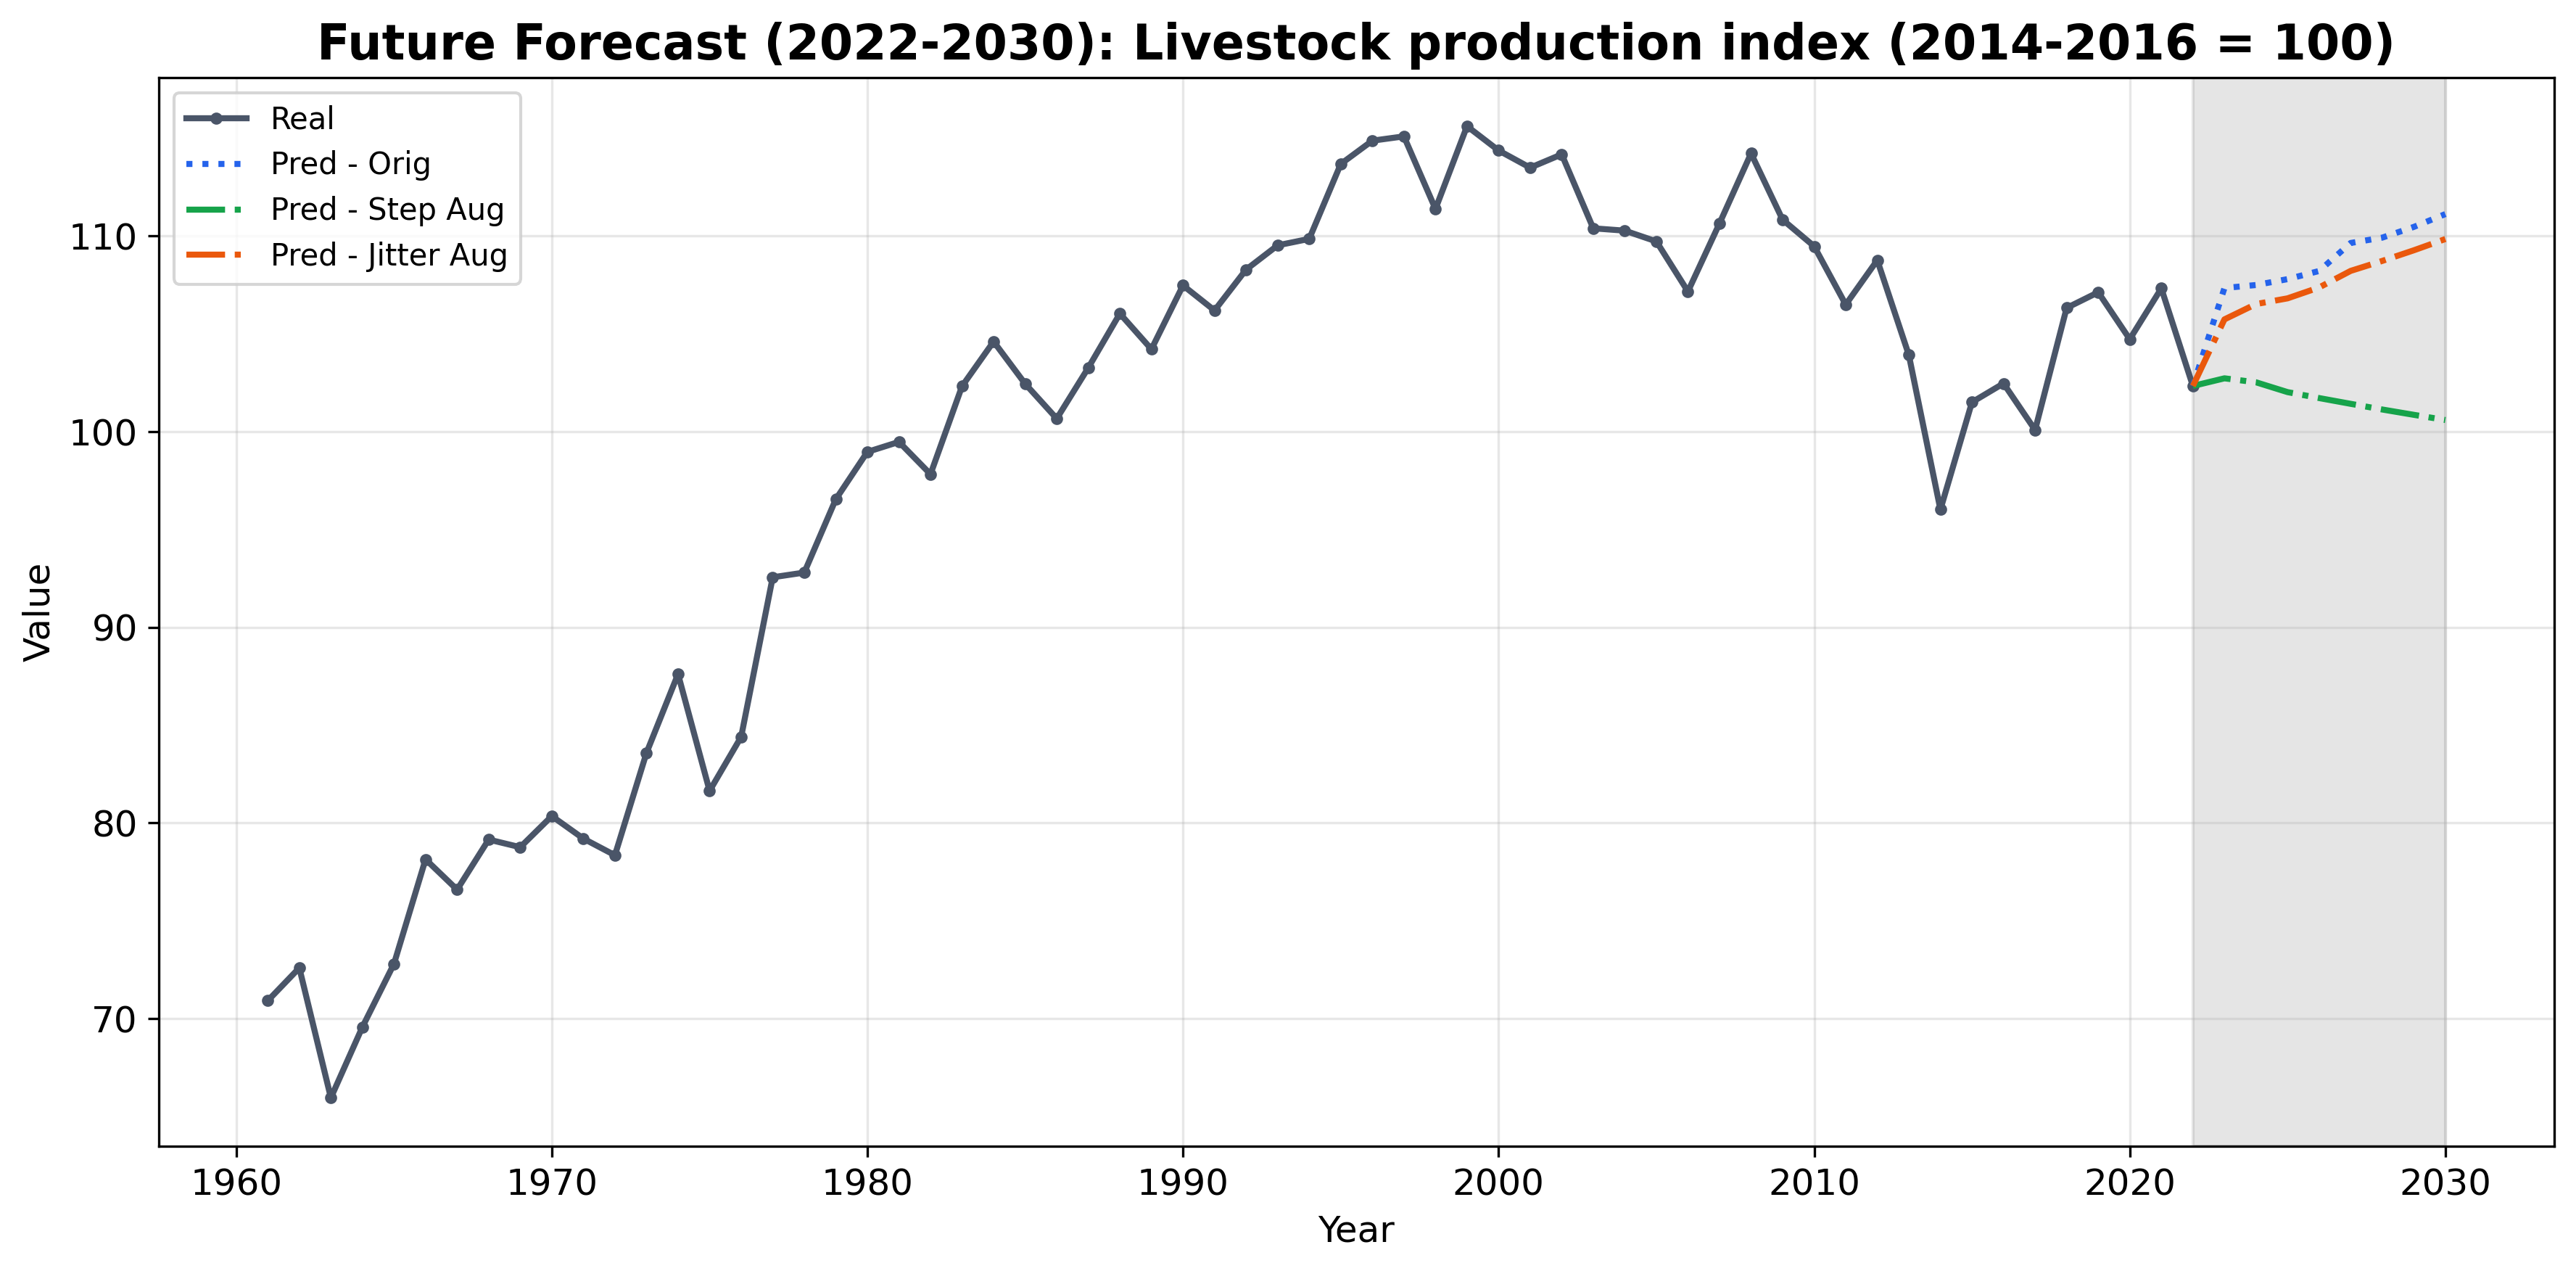

In [32]:
for indicator in forecasts_2030.keys():
    df_train = orig_aug_subsets[indicator]['orig_train']
    df_val = orig_aug_subsets[indicator]['orig_val']
    df_test = orig_aug_subsets[indicator]['orig_test']
    
    plot_future_forecasts(
        variable_name=indicator,
        predictions_dict=forecasts_2030,
        train_df=df_train,
        val_df=df_val,
        test_df=df_test,
        model_name="CNN_shallow_2030"
    )